<a href="https://colab.research.google.com/github/laiba329/AIC354-Machine-Learning-Fundamentals/blob/main/Classification_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Workflow on Breast Cancer Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
data = load_breast_cancer()
X_bc = pd.DataFrame(data.data, columns=data.feature_names)
y_bc = pd.Series(data.target)

print("First 5 rows of the Breast Cancer dataset (features):")
display(X_bc.head())

print("\nTarget variable distribution:")
display(y_bc.value_counts())

print("\nDataset Information:")
display(X_bc.info())

print("\nMissing values:")
display(X_bc.isnull().sum().sum())

# Split data into training and testing sets
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc)

print(f"\nX_train shape: {X_train_bc.shape}")
print(f"y_train shape: {y_train_bc.shape}")
print(f"X_test shape: {X_test_bc.shape}")
print(f"y_test shape: {y_test_bc.shape}")

First 5 rows of the Breast Cancer dataset (features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target variable distribution:


,count
1,357
0,212



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoo

None


Missing values:


np.int64(0)


X_train shape: (455, 30)
y_train shape: (455,)
X_test shape: (114, 30)
y_test shape: (114,)


## Data Preprocessing

For the Breast Cancer dataset, all features are numerical. We will apply `StandardScaler` to normalize them.

In [3]:
# Define numerical features (all are numerical in Breast Cancer dataset)
numerical_features_bc = X_bc.columns.tolist()

# Create a column transformer for preprocessing (only StandardScaler for numerical features)
preprocessor_bc = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_bc)
    ])

## 1. Logistic Regression

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC: 0.9957


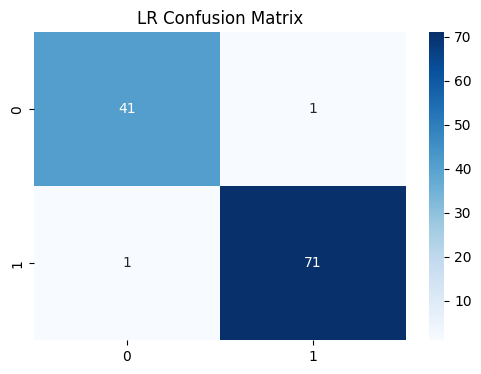

In [4]:
# Create a pipeline for Logistic Regression
model_pipeline_lr_bc = Pipeline(steps=[
    ('preprocessor', preprocessor_bc),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train the model
model_pipeline_lr_bc.fit(X_train_bc, y_train_bc)

# Make predictions
y_pred_lr_bc = model_pipeline_lr_bc.predict(X_test_bc)
y_pred_proba_lr_bc = model_pipeline_lr_bc.predict_proba(X_test_bc)[:, 1]

# Evaluate
accuracy_bc = accuracy_score(y_test_bc, y_pred_lr_bc)
precision_bc = precision_score(y_test_bc, y_pred_lr_bc)
recall_bc = recall_score(y_test_bc, y_pred_lr_bc)
f1_bc = f1_score(y_test_bc, y_pred_lr_bc)
roc_auc_bc = roc_auc_score(y_test_bc, y_pred_proba_lr_bc)

print("Logistic Regression Classification Report:")
print(classification_report(y_test_bc, y_pred_lr_bc))
print(f"AUC: {roc_auc_bc:.4f}")

cm_lr_bc = confusion_matrix(y_test_bc, y_pred_lr_bc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr_bc, annot=True, fmt='d', cmap='Blues')
plt.title('LR Confusion Matrix')
plt.show()

## 2. Decision Tree

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        42
           1       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

AUC: 0.9163


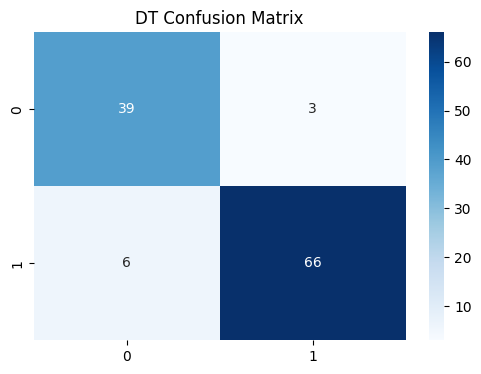

In [5]:
# Create a pipeline for Decision Tree
model_pipeline_dt_bc = Pipeline(steps=[
    ('preprocessor', preprocessor_bc),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5))
])

# Train the model
model_pipeline_dt_bc.fit(X_train_bc, y_train_bc)

# Make predictions
y_pred_dt_bc = model_pipeline_dt_bc.predict(X_test_bc)
y_pred_proba_dt_bc = model_pipeline_dt_bc.predict_proba(X_test_bc)[:, 1]

# Evaluate
dt_accuracy_bc = accuracy_score(y_test_bc, y_pred_dt_bc)
dt_precision_bc = precision_score(y_test_bc, y_pred_dt_bc)
dt_recall_bc = recall_score(y_test_bc, y_pred_dt_bc)
dt_f1_bc = f1_score(y_test_bc, y_pred_dt_bc)
dt_roc_auc_bc = roc_auc_score(y_test_bc, y_pred_proba_dt_bc)

print("Decision Tree Classification Report:")
print(classification_report(y_test_bc, y_pred_dt_bc))
print(f"AUC: {dt_roc_auc_bc:.4f}")

cm_dt_bc = confusion_matrix(y_test_bc, y_pred_dt_bc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt_bc, annot=True, fmt='d', cmap='Blues')
plt.title('DT Confusion Matrix')
plt.show()

## 3. Naive Bayes

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        42
           1       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

AUC: 0.9868


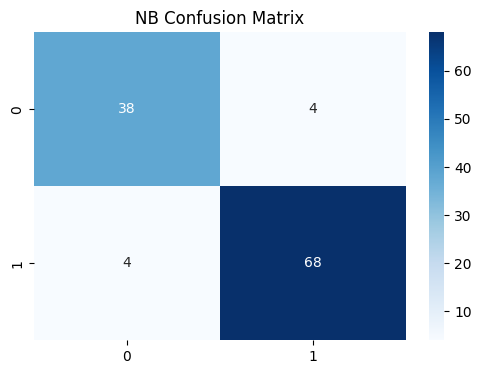

In [6]:
# Create a pipeline for Naive Bayes
model_pipeline_nb_bc = Pipeline(steps=[
    ('preprocessor', preprocessor_bc),
    ('classifier', GaussianNB())
])

# Train the model
model_pipeline_nb_bc.fit(X_train_bc, y_train_bc)

# Make predictions
y_pred_nb_bc = model_pipeline_nb_bc.predict(X_test_bc)
y_pred_proba_nb_bc = model_pipeline_nb_bc.predict_proba(X_test_bc)[:, 1]

# Evaluate
nb_accuracy_bc = accuracy_score(y_test_bc, y_pred_nb_bc)
nb_precision_bc = precision_score(y_test_bc, y_pred_nb_bc)
nb_recall_bc = recall_score(y_test_bc, y_pred_nb_bc)
nb_f1_bc = f1_score(y_test_bc, y_pred_nb_bc)
nb_roc_auc_bc = roc_auc_score(y_test_bc, y_pred_proba_nb_bc)

print("Naive Bayes Classification Report:")
print(classification_report(y_test_bc, y_pred_nb_bc))
print(f"AUC: {nb_roc_auc_bc:.4f}")

cm_nb_bc = confusion_matrix(y_test_bc, y_pred_nb_bc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_nb_bc, annot=True, fmt='d', cmap='Blues')
plt.title('NB Confusion Matrix')
plt.show()

## 4. Support Vector Machine (SVM)

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC: 0.9950


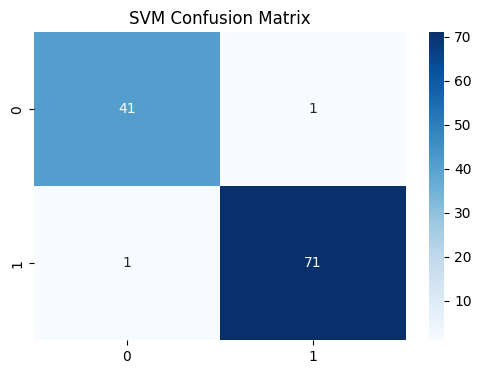

In [7]:
# Create a pipeline for SVM
model_pipeline_svm_bc = Pipeline(steps=[
    ('preprocessor', preprocessor_bc),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])

# Train the model
model_pipeline_svm_bc.fit(X_train_bc, y_train_bc)

# Make predictions
y_pred_svm_bc = model_pipeline_svm_bc.predict(X_test_bc)
y_pred_proba_svm_bc = model_pipeline_svm_bc.predict_proba(X_test_bc)[:, 1]

# Evaluate
svm_accuracy_bc = accuracy_score(y_test_bc, y_pred_svm_bc)
svm_precision_bc = precision_score(y_test_bc, y_pred_svm_bc)
svm_recall_bc = recall_score(y_test_bc, y_pred_svm_bc)
svm_f1_bc = f1_score(y_test_bc, y_pred_svm_bc)
svm_roc_auc_bc = roc_auc_score(y_test_bc, y_pred_proba_svm_bc)

print("SVM Classification Report:")
print(classification_report(y_test_bc, y_pred_svm_bc))
print(f"AUC: {svm_roc_auc_bc:.4f}")

cm_svm_bc = confusion_matrix(y_test_bc, y_pred_svm_bc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm_bc, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.show()

## Model Comparison


--- Model Comparison (Breast Cancer Dataset) ---

Comparison of Model Metrics:


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995701
Decision Tree,0.921053,0.956522,0.916667,0.936170,0.916336
Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772
SVM,0.982456,0.986111,0.986111,0.986111,0.995040


<Figure size 1200x700 with 0 Axes>

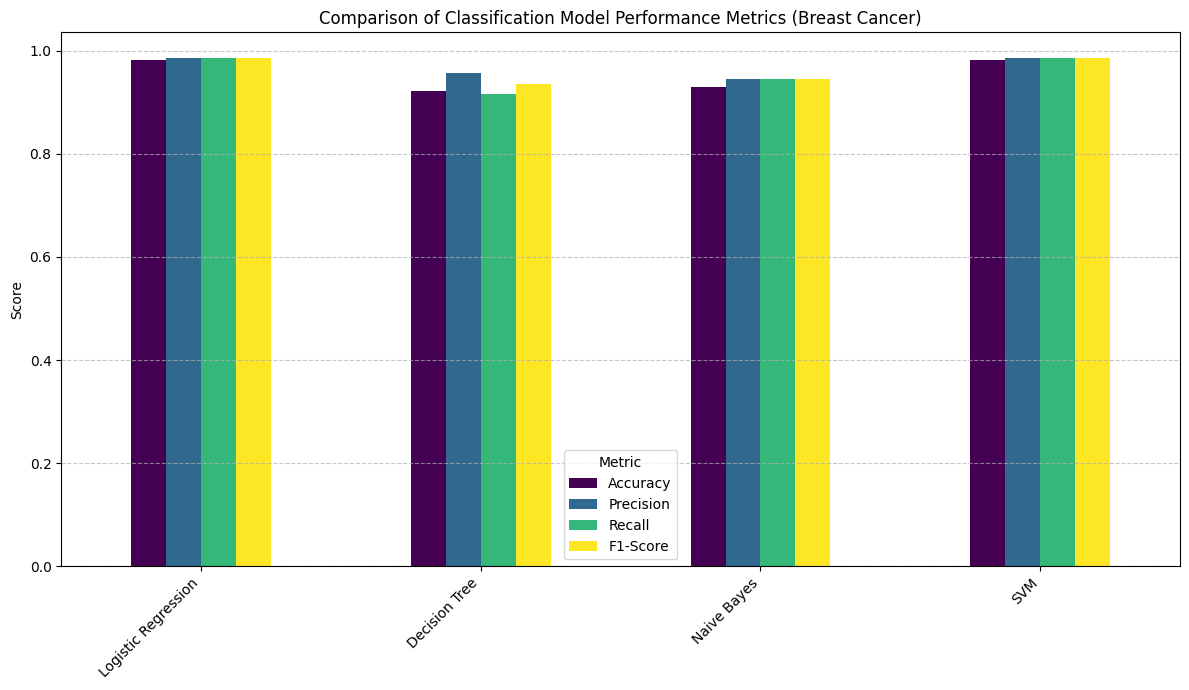


AUC Score Comparison:
Logistic Regression: AUC = 0.9957
Decision Tree: AUC = 0.9163
Naive Bayes: AUC = 0.9868
SVM: AUC = 0.9950


In [8]:
print("\n--- Model Comparison (Breast Cancer Dataset) ---")

# Create a dictionary to store metrics for each model
metrics_bc = {
    'Logistic Regression': {
        'Accuracy': accuracy_bc,
        'Precision': precision_bc,
        'Recall': recall_bc,
        'F1-Score': f1_bc,
        'AUC': roc_auc_bc
    },
    'Decision Tree': {
        'Accuracy': dt_accuracy_bc,
        'Precision': dt_precision_bc,
        'Recall': dt_recall_bc,
        'F1-Score': dt_f1_bc,
        'AUC': dt_roc_auc_bc
    },
    'Naive Bayes': {
        'Accuracy': nb_accuracy_bc,
        'Precision': nb_precision_bc,
        'Recall': nb_recall_bc,
        'F1-Score': nb_f1_bc,
        'AUC': nb_roc_auc_bc
    },
    'SVM': {
        'Accuracy': svm_accuracy_bc,
        'Precision': svm_precision_bc,
        'Recall': svm_recall_bc,
        'F1-Score': svm_f1_bc,
        'AUC': svm_roc_auc_bc
    }
}

# Convert metrics to a DataFrame for easier plotting
metrics_df_bc = pd.DataFrame(metrics_bc).T

print("\nComparison of Model Metrics:")
display(metrics_df_bc)

# Plotting the metrics
metrics_to_plot_bc = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(12, 7))
metrics_df_bc[metrics_to_plot_bc].plot(kind='bar', figsize=(12, 7), cmap='viridis')
plt.title('Comparison of Classification Model Performance Metrics (Breast Cancer)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nAUC Score Comparison:")
for model_name, model_metrics in metrics_bc.items():
    print(f"{model_name}: AUC = {model_metrics['AUC']:.4f}")

## Combined ROC Curves

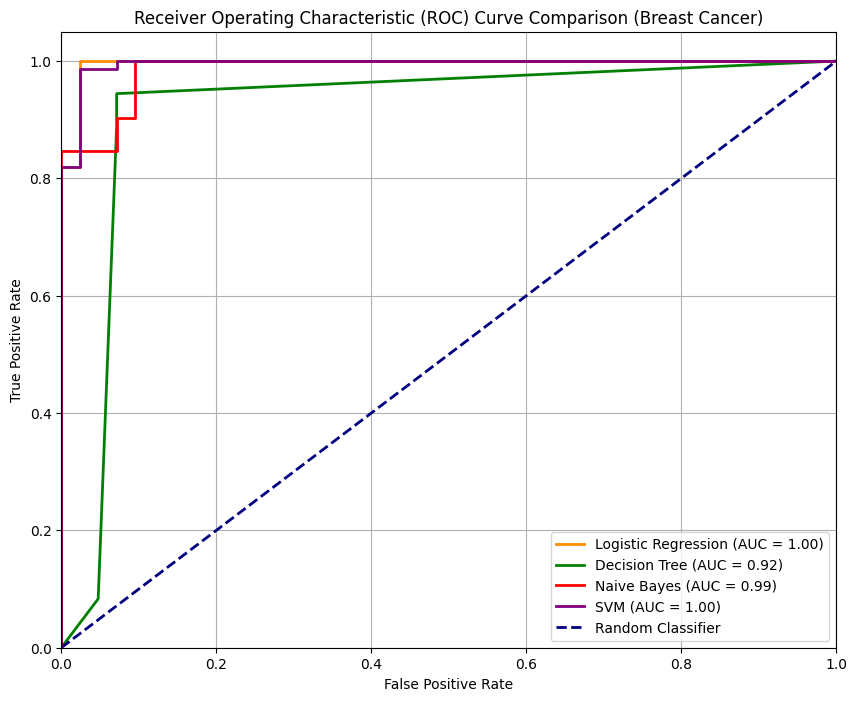

In [9]:
plt.figure(figsize=(10, 8))

# Logistic Regression ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_bc, y_pred_proba_lr_bc)
auc_lr = roc_auc_score(y_test_bc, y_pred_proba_lr_bc)
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# Decision Tree ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_bc, y_pred_proba_dt_bc)
auc_dt = roc_auc_score(y_test_bc, y_pred_proba_dt_bc)
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt:.2f})')

# Naive Bayes ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test_bc, y_pred_proba_nb_bc)
auc_nb = roc_auc_score(y_test_bc, y_pred_proba_nb_bc)
plt.plot(fpr_nb, tpr_nb, color='red', lw=2, label=f'Naive Bayes (AUC = {auc_nb:.2f})')

# SVM ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test_bc, y_pred_proba_svm_bc)
auc_svm = roc_auc_score(y_test_bc, y_pred_proba_svm_bc)
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'SVM (AUC = {auc_svm:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison (Breast Cancer)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## K-Fold Cross-Validation for Logistic Regression

To further validate the performance of our best-performing model (Logistic Regression in this case), we will perform k-fold cross-validation. This technique provides a more reliable estimate of model performance by training and evaluating the model multiple times on different subsets of the data.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Define the number of folds
k_folds = 5

# Initialize StratifiedKFold for classification tasks to maintain class proportions
# We use y_bc (the original target series for the whole dataset) for splitting
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Create a pipeline for Logistic Regression, similar to the one used before
# This pipeline includes the preprocessor_bc and the LogisticRegression classifier
model_pipeline_lr_cv = Pipeline(steps=[
    ('preprocessor', preprocessor_bc),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Perform cross-validation
# We use the full dataset (X_bc, y_bc) as cross_val_score will handle splitting it internally
cv_scores = cross_val_score(model_pipeline_lr_cv, X_bc, y_bc, cv=skf, scoring='accuracy', n_jobs=-1)

print(f"Logistic Regression {k_folds}-Fold Cross-Validation Accuracy:")
print(f"Scores for each fold: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of Accuracy: {cv_scores.std():.4f}")

# Optionally, you can also collect other metrics
cv_precision = cross_val_score(model_pipeline_lr_cv, X_bc, y_bc, cv=skf, scoring='precision', n_jobs=-1)
cv_recall = cross_val_score(model_pipeline_lr_cv, X_bc, y_bc, cv=skf, scoring='recall', n_jobs=-1)
cv_f1 = cross_val_score(model_pipeline_lr_cv, X_bc, y_bc, cv=skf, scoring='f1', n_jobs=-1)
cv_roc_auc = cross_val_score(model_pipeline_lr_cv, X_bc, y_bc, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"\nMean Precision: {cv_precision.mean():.4f}")
print(f"Mean Recall: {cv_recall.mean():.4f}")
print(f"Mean F1-Score: {cv_f1.mean():.4f}")
print(f"Mean AUC: {cv_roc_auc.mean():.4f}")

Logistic Regression 5-Fold Cross-Validation Accuracy:
Scores for each fold: [0.97368421 0.95614035 0.96491228 0.99122807 0.99115044]
Mean Accuracy: 0.9754
Standard Deviation of Accuracy: 0.0140

Mean Precision: 0.9707
Mean Recall: 0.9916
Mean F1-Score: 0.9807
Mean AUC: 0.9954


# Titanic Classification Workflow (Re-running to define variables for comparison)

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

# Load the Titanic dataset
titanic_df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Drop irrelevant features
titanic_df = titanic_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# Handle missing 'Age' values by filling with the median
titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)

# Handle missing 'Embarked' values by filling with the most frequent value (mode)
titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0], inplace=True)

# Separate features (X) and target (y)
X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

# Define categorical and numerical features
categorical_features = ['Sex', 'Embarked']
numerical_features = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

/tmp/ipykernel_8705/4094327612.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].median(), inplace=True)
/tmp/ipykernel_8705/4094327612.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

### Logistic Regression (Titanic Metrics)

In [12]:
# Create and train Logistic Regression pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
model_pipeline.fit(X_train, y_train)

# Make predictions and calculate metrics
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"LR Accuracy: {accuracy:.4f}")

LR Accuracy: 0.8045


### Decision Tree (Titanic Metrics)

In [13]:
# Create and train Decision Tree pipeline
dt_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, max_depth=5))
])
dt_model_pipeline.fit(X_train, y_train)

# Make predictions and calculate metrics
dt_y_pred = dt_model_pipeline.predict(X_test)
dt_y_pred_proba = dt_model_pipeline.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred)
dt_recall = recall_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred)
dt_roc_auc = roc_auc_score(y_test, dt_y_pred_proba)

print(f"DT Accuracy: {dt_accuracy:.4f}")

DT Accuracy: 0.7654


### Naive Bayes (Titanic Metrics)

In [14]:
# Create and train Naive Bayes pipeline
nb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])
nb_model_pipeline.fit(X_train, y_train)

# Make predictions and calculate metrics
nb_y_pred = nb_model_pipeline.predict(X_test)
nb_y_pred_proba = nb_model_pipeline.predict_proba(X_test)[:, 1]

nb_accuracy = accuracy_score(y_test, nb_y_pred)
nb_precision = precision_score(y_test, nb_y_pred)
nb_recall = recall_score(y_test, nb_y_pred)
nb_f1 = f1_score(y_test, nb_y_pred)
nb_roc_auc = roc_auc_score(y_test, nb_y_pred_proba)

print(f"NB Accuracy: {nb_accuracy:.4f}")

NB Accuracy: 0.7877


### Support Vector Machine (Titanic Metrics)

In [15]:
# Create and train SVM pipeline
svm_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='rbf', random_state=42, probability=True))
])
svm_model_pipeline.fit(X_train, y_train)

# Make predictions and calculate metrics
svm_y_pred = svm_model_pipeline.predict(X_test)
svm_y_pred_proba = svm_model_pipeline.predict_proba(X_test)[:, 1]

svm_accuracy = accuracy_score(y_test, svm_y_pred)
svm_precision = precision_score(y_test, svm_y_pred)
svm_recall = recall_score(y_test, svm_y_pred)
svm_f1 = f1_score(y_test, svm_y_pred)
svm_roc_auc = roc_auc_score(y_test, svm_y_pred_proba)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.8156



--- Model Comparison ---

Comparison of Model Metrics:


,Accuracy,Precision,Recall,F1-Score,AUC
Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.844401
Decision Tree,0.765363,0.754717,0.579710,0.655738,0.797101
Naive Bayes,0.787709,0.738462,0.695652,0.716418,0.818841
SVM,0.815642,0.821429,0.666667,0.736000,0.839130


<Figure size 1200x700 with 0 Axes>

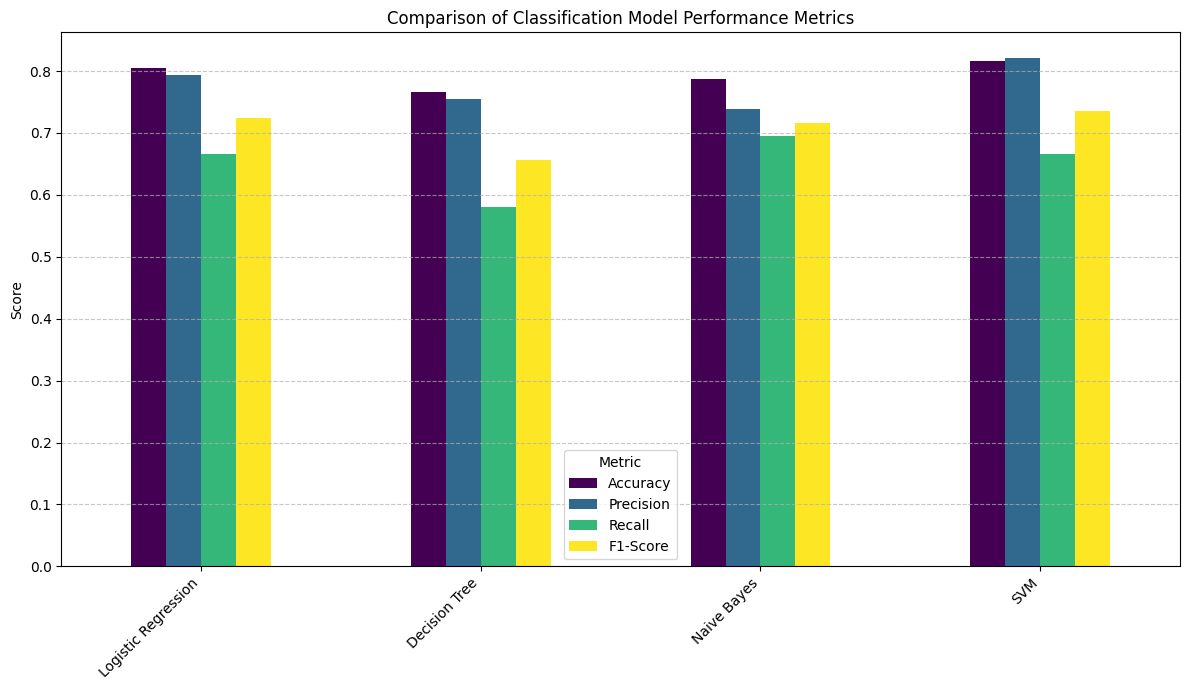


AUC Score Comparison:
Logistic Regression: AUC = 0.8444
Decision Tree: AUC = 0.7971
Naive Bayes: AUC = 0.8188
SVM: AUC = 0.8391


In [16]:
print("\n--- Model Comparison ---")

# Create a dictionary to store metrics for each model
metrics = {
    'Logistic Regression': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC': roc_auc
    },
    'Decision Tree': {
        'Accuracy': dt_accuracy,
        'Precision': dt_precision,
        'Recall': dt_recall,
        'F1-Score': dt_f1,
        'AUC': dt_roc_auc
    },
    'Naive Bayes': {
        'Accuracy': nb_accuracy,
        'Precision': nb_precision,
        'Recall': nb_recall,
        'F1-Score': nb_f1,
        'AUC': nb_roc_auc
    },
    'SVM': {
        'Accuracy': svm_accuracy,
        'Precision': svm_precision,
        'Recall': svm_recall,
        'F1-Score': svm_f1,
        'AUC': svm_roc_auc
    }
}

# Convert metrics to a DataFrame for easier plotting
metrics_df = pd.DataFrame(metrics).T

print("\nComparison of Model Metrics:")
display(metrics_df)

# Plotting the metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(12, 7))
metrics_df[metrics_to_plot].plot(kind='bar', figsize=(12, 7), cmap='viridis')
plt.title('Comparison of Classification Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nAUC Score Comparison:")
for model_name, model_metrics in metrics.items():
    print(f"{model_name}: AUC = {model_metrics['AUC']:.4f}")

## Combined ROC Curves (Titanic)

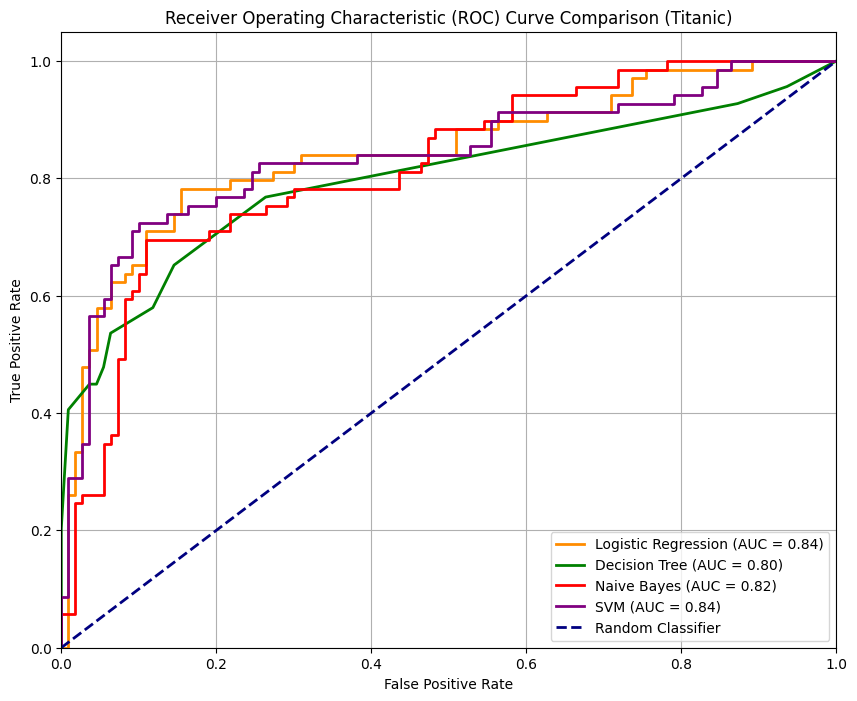

In [17]:
plt.figure(figsize=(10, 8))

# Logistic Regression ROC Curve
fpr_lr_titanic, tpr_lr_titanic, _ = roc_curve(y_test, y_pred_proba)
auc_lr_titanic = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr_lr_titanic, tpr_lr_titanic, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_lr_titanic:.2f})')

# Decision Tree ROC Curve
fpr_dt_titanic, tpr_dt_titanic, _ = roc_curve(y_test, dt_y_pred_proba)
auc_dt_titanic = roc_auc_score(y_test, dt_y_pred_proba)
plt.plot(fpr_dt_titanic, tpr_dt_titanic, color='green', lw=2, label=f'Decision Tree (AUC = {auc_dt_titanic:.2f})')

# Naive Bayes ROC Curve
fpr_nb_titanic, tpr_nb_titanic, _ = roc_curve(y_test, nb_y_pred_proba)
auc_nb_titanic = roc_auc_score(y_test, nb_y_pred_proba)
plt.plot(fpr_nb_titanic, tpr_nb_titanic, color='red', lw=2, label=f'Naive Bayes (AUC = {auc_nb_titanic:.2f})')

# SVM ROC Curve
fpr_svm_titanic, tpr_svm_titanic, _ = roc_curve(y_test, svm_y_pred_proba)
auc_svm_titanic = roc_auc_score(y_test, svm_y_pred_proba)
plt.plot(fpr_svm_titanic, tpr_svm_titanic, color='purple', lw=2, label=f'SVM (AUC = {auc_svm_titanic:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison (Titanic)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()